# Notebook 01 — Exploratory Data Analysis
**DNSC 6330 Capstone | HMDA LAR 2024**

Goals:
- Understand raw distributions, class balance, missingness, and group base rates
- Establish a **pre-model fairness baseline** before any modeling
- Flag data quality issues for Notebook 02 (preprocessing)

## 0. Imports & Paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
import csv

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'Data')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR = os.path.join(BASE_DIR, 'tables')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

print('Imports OK')
print(f'Working dir: {BASE_DIR}')
print(f'Data dir:    {DATA_DIR}')
print(f'Figures dir: {FIGURES_DIR}')
print(f'Tables dir:  {TABLES_DIR}')

Imports OK
Working dir: /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code
Data dir:    /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/Data
Figures dir: /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/figures
Tables dir:  /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables


## 1. Inspect Column Names

Resolve the raw HMDA file from `Code/Data/`, convert the text export to CSV if needed, and read only the header row before the full chunked load.

In [2]:
raw_candidates = [
    os.path.join(DATA_DIR, '2024_lar.csv'),
    os.path.join(BASE_DIR, '2024_lar.csv'),
]
txt_candidates = [
    os.path.join(DATA_DIR, '2024_lar.txt'),
    os.path.join(BASE_DIR, '2024_lar.txt'),
]

RAW_PATH = next((p for p in raw_candidates if os.path.exists(p)), None)
TXT_PATH = next((p for p in txt_candidates if os.path.exists(p)), None)

if RAW_PATH is None and TXT_PATH is not None:
    RAW_PATH = os.path.join(os.path.dirname(TXT_PATH), '2024_lar.csv')
    print(f'Converting text file to CSV: {TXT_PATH} -> {RAW_PATH}')
    with open(TXT_PATH, 'r', newline='') as fin, open(RAW_PATH, 'w', newline='') as fout:
        reader = csv.reader(fin, delimiter='|')
        writer = csv.writer(fout)
        writer.writerows(reader)

if RAW_PATH is None:
    raise FileNotFoundError(
        'Could not find 2024_lar.csv or 2024_lar.txt in Code/ or Code/Data/. '
        'Place the raw HMDA file in Code/Data/ before running NB01.'
    )

actual_cols = pd.read_csv(RAW_PATH, nrows=0).columns.tolist()
print(f'Using raw file: {RAW_PATH}')
print(f'Total columns in file: {len(actual_cols)}')
for c in actual_cols:
    print(f'  {c}')

Using raw file: /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/Data/2024_lar.csv
Total columns in file: 99
  activity_year
  lei
  derived_msa_md
  state_code
  county_code
  census_tract
  conforming_loan_limit
  derived_loan_product_type
  derived_dwelling_category
  derived_ethnicity
  derived_race
  derived_sex
  action_taken
  purchaser_type
  preapproval
  loan_type
  loan_purpose
  lien_status
  reverse_mortgage
  open_end_line_of_credit
  business_or_commercial_purpose
  loan_amount
  combined_loan_to_value_ratio
  interest_rate
  rate_spread
  hoepa_status
  total_loan_costs
  total_points_and_fees
  origination_charges
  discount_points
  lender_credits
  loan_term
  prepayment_penalty_term
  intro_rate_period
  negative_amortization
  interest_only_payment
  balloon_payment
  other_nonamortizing_features
  property_value
  construction_method
  occupancy_type
  manufactured_home_secured_property_type
  manufactured_home_land_property_interest
  total

In [3]:
# RAW_PATH and actual_cols are resolved above. Chunked loading begins below.

## 2. Chunked Load with Label Creation

The 2024 HMDA national LAR file is too large to load in one pass.
We filter and label **inside** each chunk to avoid holding the full file in memory.

Per capstone specification:
- `action_taken` values **1 and 2** → label **1** (approved)
- `action_taken` value **3** → label **0** (denied)
- All other values → **filtered out**

> **Note:** Filtering values 4–8 introduces **sample selection bias** — withdrawn/incomplete applications are non-random and may differ systematically by protected group.

In [4]:
# Columns confirmed present in 2024 HMDA LAR
# combined_loan_to_value_ratio does NOT exist in 2024 — removed from spec
# co-applicant_age uses underscore — fixed from original hyphen
# loan_to_value_ratio does NOT exist in 2024 — removed from spec
#
# Changes from original
# REMOVED: loan_to_value_ratio        (does not exist in 2024 file)
#          co-applicant_age           (hyphen typo — replaced with co_applicant_age)
#
# ADDED:   loan_term                  (15 vs 30 yr is a real risk differentiator)
#          conforming_loan_limit      (whether loan meets GSE standards, strong signal)
#          preapproval                (borrower sophistication indicator — monitor for proxy risk)
#          submission_of_application  (broker vs direct — monitor for proxy risk)
#          applicant_credit_score_type      (primary applicant credit signal)
#          co_applicant_credit_score_type   (co-applicant credit signal)
# ─────────────────────────────────────────────────────────────────────────────

DESIRED_COLS = [
    'action_taken',
    # Loan characteristics
    'loan_amount',
    'loan_type',
    'loan_purpose',
    'lien_status',
    'occupancy_type',
    'loan_term',                  # ADDED
    'conforming_loan_limit',      # ADDED
    # Applicant financials
    'income',
    'debt_to_income_ratio',
    'property_value',
    'applicant_credit_score_type',    # ADDED
    'co_applicant_credit_score_type', # ADDED
    # Application process — monitored for proxy risk
    'preapproval',                    # ADDED
    'submission_of_application',      # ADDED
    # Protected class — audit only, never trained on
    'derived_race',
    'derived_sex',
    'derived_ethnicity',
    'applicant_age',
    'co_applicant_age',               # FIXED (was co-applicant_age)
    # Geographic — analysis only, exclude from model features
    'state_code',
    'county_code',
    'census_tract',
]

# Only request columns that actually exist
KEEP_COLS = [c for c in DESIRED_COLS if c in actual_cols]
missing   = set(DESIRED_COLS) - set(KEEP_COLS)
if missing:
    print(f'Columns not found in file (skipped): {missing}')
print(f'Loading {len(KEEP_COLS)} columns.')

Loading 23 columns.


In [5]:
# ── Chunked load: filter + label inside each chunk ───────────────────────────
CHUNK_SIZE = 50_000   # reduce to 25_000 if still hitting memory limits

chunks    = []
total_raw = 0

for chunk in pd.read_csv(
    RAW_PATH,
    usecols=KEEP_COLS,
    low_memory=False,
    chunksize=CHUNK_SIZE
):
    total_raw += len(chunk)

    # Filter to action_taken 1, 2, 3 BEFORE any copy or map
    chunk = chunk[chunk['action_taken'].isin([1, 2, 3])]

    # Create label per capstone spec
    chunk['label'] = chunk['action_taken'].map({1: 1, 2: 1, 3: 0})

    # Drop action_taken — no longer needed
    chunk = chunk.drop(columns=['action_taken'])

    # Rename hyphenated column immediately
    if 'co-applicant_age' in chunk.columns:
        chunk = chunk.rename(columns={'co-applicant_age': 'co_applicant_age'})

    chunks.append(chunk)
    kept = sum(len(c) for c in chunks)
    print(f'  Processed {total_raw:,} rows | kept {kept:,}', end='\r')

df = pd.concat(chunks, ignore_index=True)
del chunks   # free memory immediately

print(f'\nDone.')
print(f'Raw rows seen:  {total_raw:,}')
print(f'Filtered rows:  {len(df):,} ({len(df)/total_raw:.1%} kept)')
print(f'Columns:        {df.shape[1]}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nApproval rate: {df["label"].mean():.2%}')


Done.
Raw rows seen:  12,259,151
Filtered rows:  8,661,773 (70.7% kept)
Columns:        23

Label distribution:
label
1    6558313
0    2103460
Name: count, dtype: int64

Approval rate: 75.72%


In [6]:
# action_taken breakdown (reconstructed from label + note)
ACTION_LABELS = {
    1: 'Loan originated',
    2: 'Approved, not accepted',
    3: 'Application denied',
    4: 'Application withdrawn         (filtered out)',
    5: 'File closed - incomplete      (filtered out)',
    6: 'Purchased loan                (filtered out)',
    7: 'Pre-approval denied           (filtered out)',
    8: 'Pre-approval approved, not accepted (filtered out)',
}
print('action_taken mapping used:')
for k, v in ACTION_LABELS.items():
    label = {1: '→ label=1', 2: '→ label=1', 3: '→ label=0'}.get(k, '→ dropped')
    print(f'  {k}: {v:55s} {label}')

action_taken mapping used:
  1: Loan originated                                         → label=1
  2: Approved, not accepted                                  → label=1
  3: Application denied                                      → label=0
  4: Application withdrawn         (filtered out)            → dropped
  5: File closed - incomplete      (filtered out)            → dropped
  6: Purchased loan                (filtered out)            → dropped
  7: Pre-approval denied           (filtered out)            → dropped
  8: Pre-approval approved, not accepted (filtered out)      → dropped


## 3. Basic Inspection

In [7]:
print('── Data Types ──')
print(df.dtypes)
print()
print('── First 3 rows ──')
df.head(3)

── Data Types ──
state_code                         object
county_code                       float64
census_tract                       object
conforming_loan_limit              object
derived_ethnicity                  object
derived_race                       object
derived_sex                        object
preapproval                         int64
loan_type                           int64
loan_purpose                        int64
lien_status                         int64
loan_amount                         int64
loan_term                          object
property_value                     object
occupancy_type                      int64
income                            float64
debt_to_income_ratio               object
applicant_credit_score_type         int64
co_applicant_credit_score_type      int64
applicant_age                      object
co_applicant_age                   object
submission_of_application           int64
label                               int64
dtype: object

──

,state_code,county_code,census_tract,conforming_loan_limit,derived_ethnicity,derived_race,derived_sex,preapproval,loan_type,loan_purpose,lien_status,loan_amount,loan_term,property_value,occupancy_type,income,debt_to_income_ratio,applicant_credit_score_type,co_applicant_credit_score_type,applicant_age,co_applicant_age,submission_of_application,label
0,GA,13081.0000,13081010100.0000,C,Not Hispanic or Latino,Black or African American,Female,2,1,31,1,15000,Exempt,Exempt,1,31.0000,Exempt,1111,1111,55-64,9999,1111,1
1,GA,13017.0000,13017960502.0000,C,Hispanic or Latino,White,Male,2,1,1,1,15000,Exempt,Exempt,3,43.0000,Exempt,1111,1111,25-34,9999,1111,1
2,GA,13071.0000,13071970703.0000,C,Not Hispanic or Latino,White,Male,2,1,31,1,15000,Exempt,Exempt,3,69.0000,Exempt,1111,1111,35-44,9999,1111,1


## 4. Class Balance

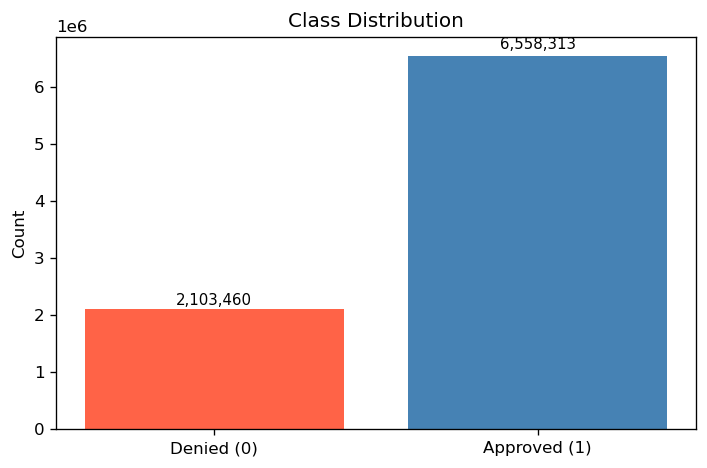

Note: values 1 and 2 are both coded as approved (label=1).
Value 2 (approved but not accepted) reflects borrower behavior, not lender decision.


In [8]:
# Visualize class balance
label_counts = df['label'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Denied (0)', 'Approved (1)'], label_counts[[0, 1]],
       color=['tomato', 'steelblue'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for i, v in enumerate(label_counts[[0, 1]]):
    ax.text(i, v + v * 0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_class_balance.png'))
plt.show()

print('Note: values 1 and 2 are both coded as approved (label=1).')
print('Value 2 (approved but not accepted) reflects borrower behavior, not lender decision.')

## 5. Feature Groups

In [9]:
# Define feature groups — filter to columns that exist in this load
NUMERIC_FEATURES = [
    'loan_amount', 'income', 'property_value',
    'debt_to_income_ratio', 'loan_to_value_ratio',
    'loan_term',                        # ADDED
]
CATEGORICAL_FEATURES = [
    'loan_type', 'loan_purpose', 'occupancy_type', 'lien_status',
    'conforming_loan_limit',            # ADDED — encoded as C/NC/U in HMDA
    'preapproval',                      # ADDED — monitor for proxy risk
    'submission_of_application',        # ADDED — monitor for proxy risk
    'applicant_credit_score_type',      # ADDED
    'co_applicant_credit_score_type',   # ADDED
]
PROTECTED_FEATURES = [
    'derived_race', 'derived_sex', 'derived_ethnicity',
    'applicant_age', 'co_applicant_age',
]
GEO_FEATURES = ['state_code', 'county_code', 'census_tract']

# Filter each group to confirmed-present columns
NUMERIC_FEATURES     = [c for c in NUMERIC_FEATURES     if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]
PROTECTED_FEATURES   = [c for c in PROTECTED_FEATURES   if c in df.columns]
GEO_FEATURES         = [c for c in GEO_FEATURES         if c in df.columns]

print(f'Numeric features ({len(NUMERIC_FEATURES)}):     {NUMERIC_FEATURES}')
print(f'Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print(f'Protected features ({len(PROTECTED_FEATURES)}):   {PROTECTED_FEATURES}')
print(f'Geographic features ({len(GEO_FEATURES)}):   {GEO_FEATURES}')

Numeric features (5):     ['loan_amount', 'income', 'property_value', 'debt_to_income_ratio', 'loan_term']
Categorical features (9): ['loan_type', 'loan_purpose', 'occupancy_type', 'lien_status', 'conforming_loan_limit', 'preapproval', 'submission_of_application', 'applicant_credit_score_type', 'co_applicant_credit_score_type']
Protected features (5):   ['derived_race', 'derived_sex', 'derived_ethnicity', 'applicant_age', 'co_applicant_age']
Geographic features (3):   ['state_code', 'county_code', 'census_tract']


## 6. Numeric Feature Distributions

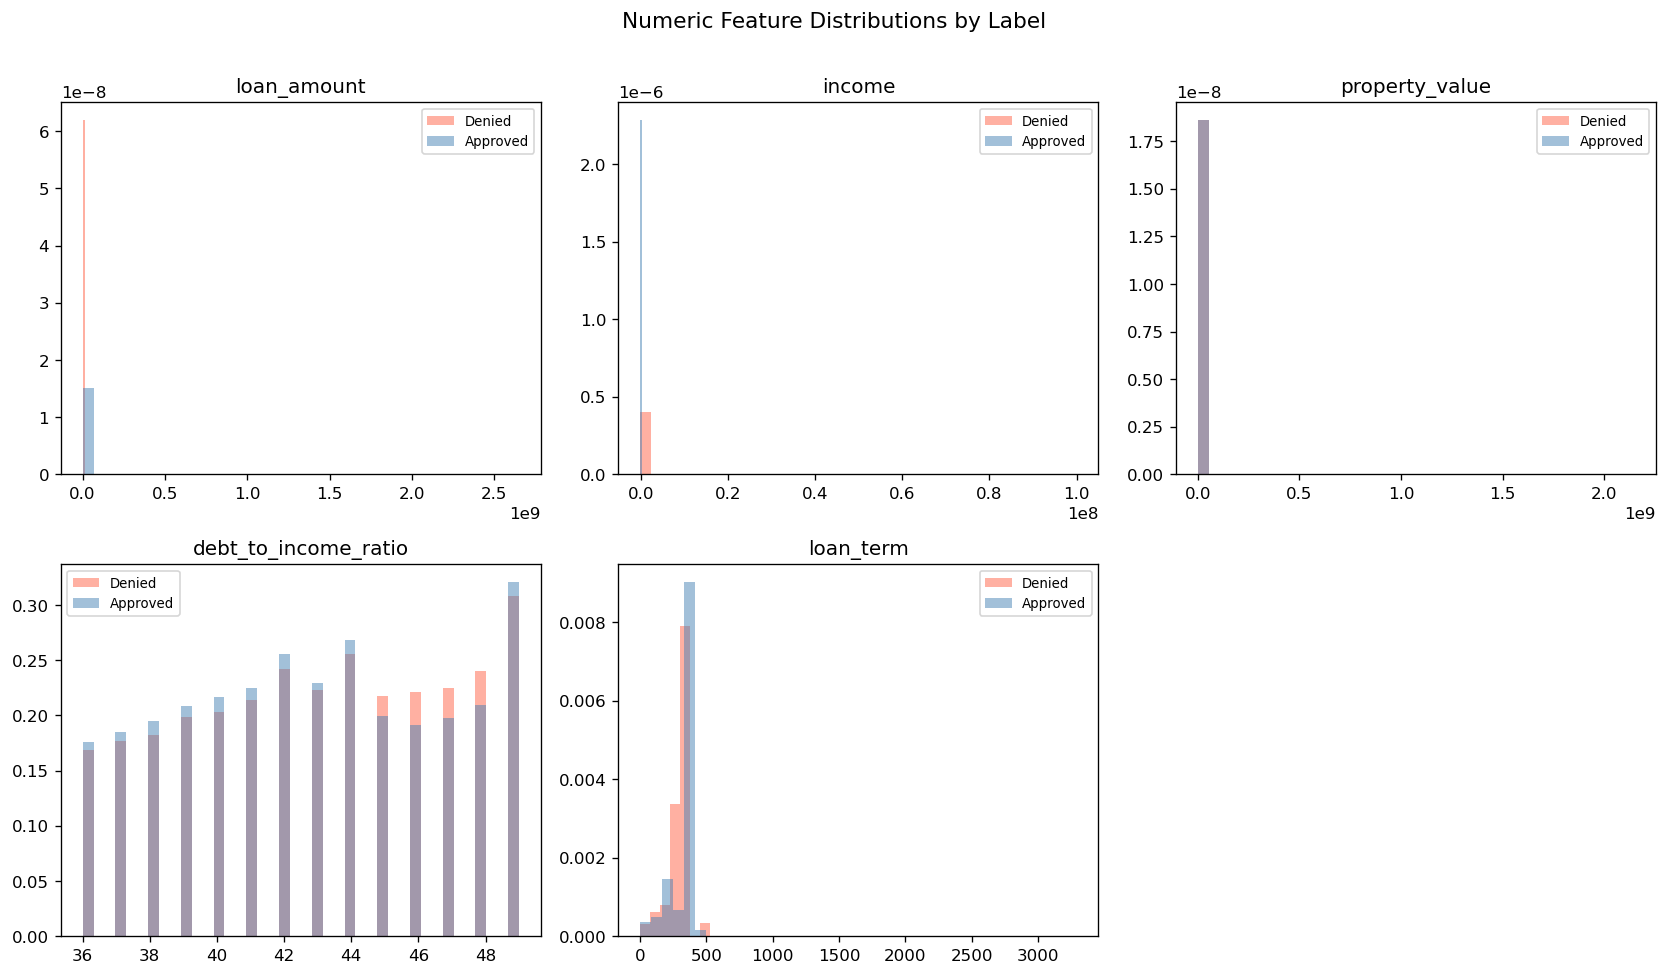

In [10]:
if NUMERIC_FEATURES:
    n_cols = min(3, len(NUMERIC_FEATURES))
    n_rows = int(np.ceil(len(NUMERIC_FEATURES) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, col in enumerate(NUMERIC_FEATURES):
        plot_col = pd.to_numeric(df[col], errors='coerce')
        for label, color, name in [(0, 'tomato', 'Denied'), (1, 'steelblue', 'Approved')]:
            axes[i].hist(
                plot_col[df['label'] == label].dropna(),
                bins=40, alpha=0.5, color=color, label=name, density=True
            )
        axes[i].set_title(col)
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric Feature Distributions by Label', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '01_numeric_distributions.png'), bbox_inches='tight')
    plt.show()

## 7. Categorical Feature Distributions

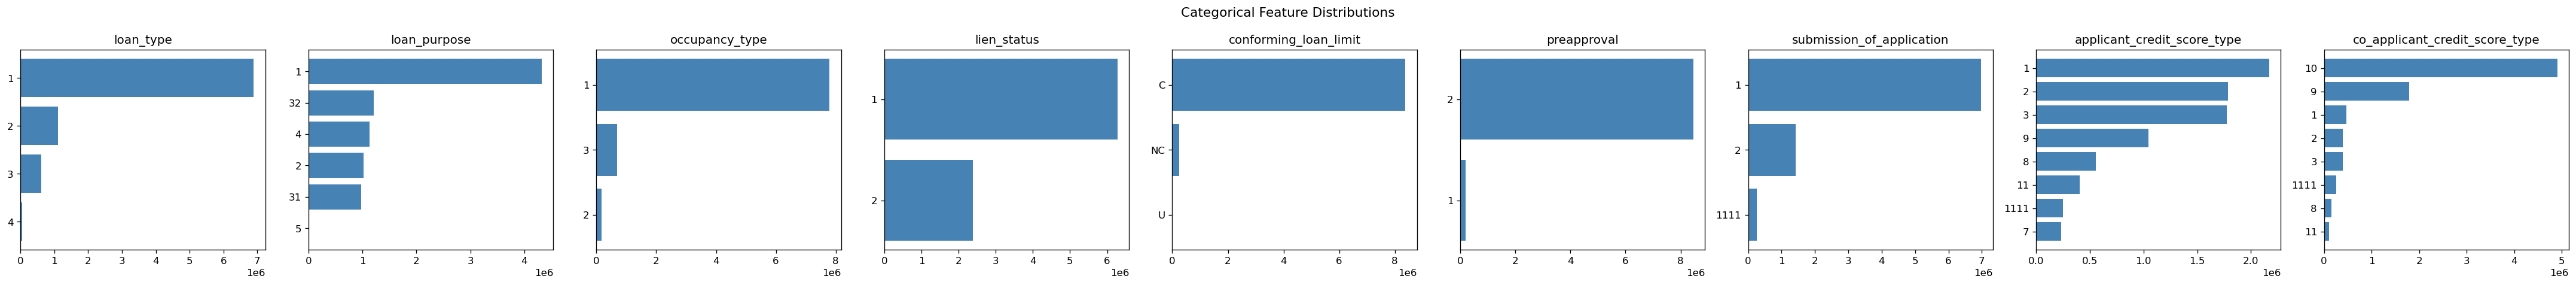

In [11]:
if CATEGORICAL_FEATURES:
    fig, axes = plt.subplots(1, len(CATEGORICAL_FEATURES),
                             figsize=(4 * len(CATEGORICAL_FEATURES), 4))
    if len(CATEGORICAL_FEATURES) == 1:
        axes = [axes]

    for i, col in enumerate(CATEGORICAL_FEATURES):
        top_vals = df[col].value_counts().head(8)
        axes[i].barh(top_vals.index.astype(str), top_vals.values, color='steelblue')
        axes[i].set_title(col)
        axes[i].invert_yaxis()

    fig.suptitle('Categorical Feature Distributions', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '01_categorical_distributions.png'), bbox_inches='tight')
    plt.show()

## 8. Missingness

In [12]:
# HMDA uses 'Exempt' and special codes as missing
HMDA_NA_VALUES = ['Exempt', 'NA', '', ' ', 'N/A', 'nan']

df_na = df.replace(HMDA_NA_VALUES, np.nan)

missing = (
    df_na.isnull().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'n_missing'})
)
missing['pct_missing'] = missing['n_missing'] / len(df_na)
missing = missing[missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)

print(f'Columns with missing values: {len(missing)} / {df_na.shape[1]}')
print(missing.to_string(index=False))

Columns with missing values: 8 / 23
               column  n_missing  pct_missing
 debt_to_income_ratio     942102       0.1088
       property_value     570043       0.0658
               income     545526       0.0630
            loan_term     412431       0.0476
         census_tract     119041       0.0137
          county_code      87858       0.0101
           state_code      45496       0.0053
conforming_loan_limit      37795       0.0044


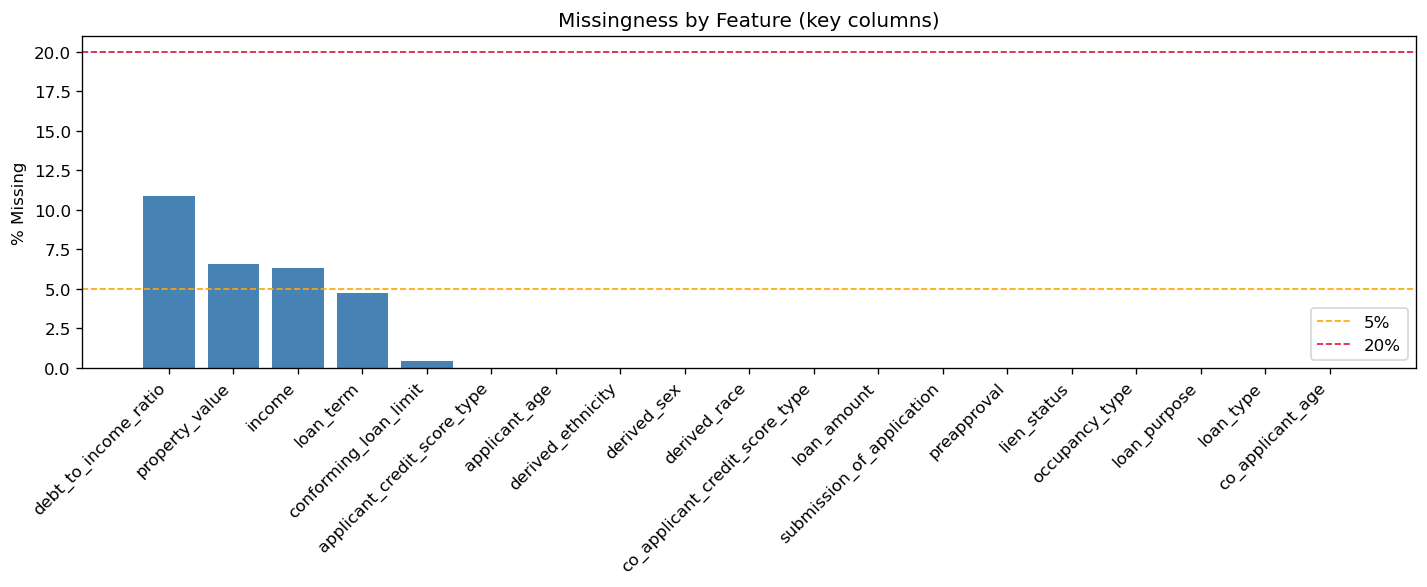

In [13]:
# Missingness bar chart for key columns only
key_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + PROTECTED_FEATURES
key_cols = [c for c in key_cols if c in df_na.columns]

miss_pct = df_na[key_cols].isnull().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(miss_pct.index, miss_pct.values * 100, color='steelblue')
ax.axhline(5,  color='orange', linestyle='--', linewidth=1, label='5%')
ax.axhline(20, color='crimson', linestyle='--', linewidth=1, label='20%')
ax.set_ylabel('% Missing')
ax.set_title('Missingness by Feature (key columns)')
ax.set_xticklabels(miss_pct.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_missingness.png'))
plt.show()

## 9. Protected Class Base Rates — Pre-Model Fairness Baseline

> This is the **pre-model fairness baseline** — approval rates by group before any model is fitted.
> Apply the **EEOC 80% rule**: any group whose approval rate is less than 80% of the maximum group's rate is flagged.

In [14]:
def approval_rate_table(df, group_col, label_col='label', min_n=50):
    """
    Compute approval rate, count, and 80% rule AIR per group.
    """
    df_clean = df.replace(HMDA_NA_VALUES, np.nan).dropna(subset=[group_col])
    stats = (
        df_clean.groupby(group_col)[label_col]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    )
    stats = stats[stats['n'] >= min_n]
    max_rate = stats['approval_rate'].max()
    stats['AIR']        = (stats['approval_rate'] / max_rate).round(4)
    stats['fails_80pct'] = stats['AIR'] < 0.80
    return stats.sort_values('approval_rate', ascending=False)


for col in PROTECTED_FEATURES:
    print(f'\n── Approval rates by {col} ──')
    tbl = approval_rate_table(df, col)
    print(tbl.to_string())
    flagged = tbl[tbl['fails_80pct']]
    if not flagged.empty:
        print(f'  ⚠ 80% rule FAILS for: {flagged.index.tolist()}')
    else:
        print('  ✓ 80% rule holds for all groups')


── Approval rates by derived_race ──


                                           approval_rate        n    AIR  fails_80pct
derived_race                                                                         
Joint                                             0.8046   189064 1.0000        False
Asian                                             0.7873   524983 0.9785        False
White                                             0.7819  5550899 0.9718        False
Race Not Available                                0.7224  1526051 0.8978        False
Black or African American                         0.6334   762461 0.7873         True
American Indian or Alaska Native                  0.6297    63158 0.7826         True
2 or more minority races                          0.6197    21855 0.7702         True
Native Hawaiian or Other Pacific Islander         0.6130    21117 0.7619         True
Free Form Text Only                               0.4105     2185 0.5102         True
  ⚠ 80% rule FAILS for: ['Black or African American', 

                   approval_rate        n    AIR  fails_80pct
derived_sex                                                  
Joint                     0.8167  3003110 1.0000        False
Male                      0.7357  2934484 0.9008        False
Sex Not Available         0.7338   772200 0.8985        False
Female                    0.7071  1951979 0.8658        False
  ✓ 80% rule holds for all groups

── Approval rates by derived_ethnicity ──


                         approval_rate        n    AIR  fails_80pct
derived_ethnicity                                                  
Joint                           0.7926   223382 1.0000        False
Not Hispanic or Latino          0.7735  5968141 0.9759        False
Ethnicity Not Available         0.7294  1410834 0.9202        False
Hispanic or Latino              0.6953  1055891 0.8773        False
Free Form Text Only             0.5146     3525 0.6493         True
  ⚠ 80% rule FAILS for: ['Free Form Text Only']

── Approval rates by applicant_age ──


               approval_rate        n    AIR  fails_80pct
applicant_age                                            
8888                  0.8645   227417 1.0000        False
25-34                 0.8147  1692175 0.9424        False
<25                   0.8013   307049 0.9269        False
35-44                 0.7647  2057697 0.8846        False
45-54                 0.7324  1794403 0.8472        False
55-64                 0.7217  1410085 0.8348        False
65-74                 0.7157   826709 0.8279        False
>74                   0.6929   346238 0.8015        False
  ✓ 80% rule holds for all groups

── Approval rates by co_applicant_age ──


                  approval_rate        n    AIR  fails_80pct
co_applicant_age                                            
8888                     0.8620    77013 1.0000        False
25-34                    0.8558   758841 0.9929        False
35-44                    0.8152   833997 0.9458        False
<25                      0.8081   138470 0.9375        False
65-74                    0.7947   371464 0.9219        False
55-64                    0.7913   584029 0.9180        False
45-54                    0.7881   705091 0.9143        False
>74                      0.7655   135771 0.8881        False
9999                     0.7185  5057097 0.8336        False
  ✓ 80% rule holds for all groups


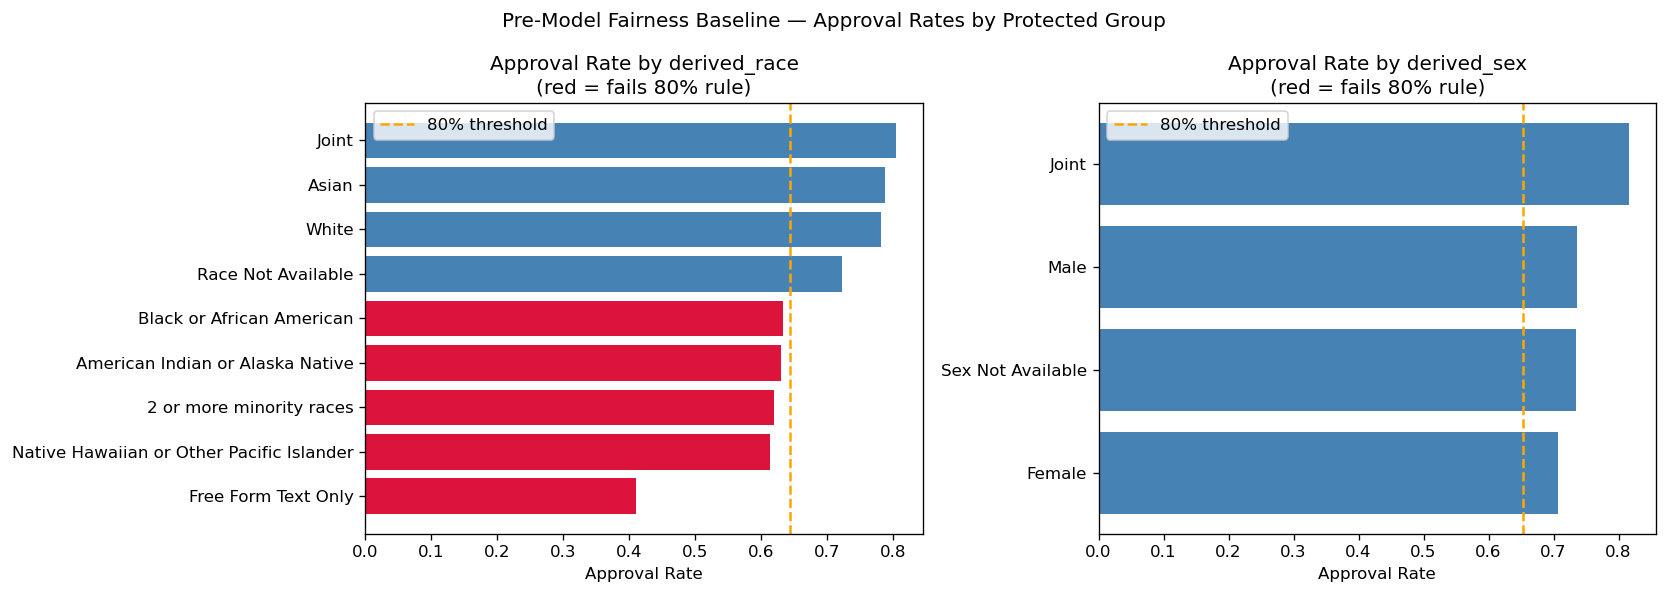

In [15]:
# Visualize approval rates by race and sex
plot_cols = [c for c in ['derived_race', 'derived_sex'] if c in PROTECTED_FEATURES]

if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(7 * len(plot_cols), 5))
    if len(plot_cols) == 1:
        axes = [axes]

    for i, col in enumerate(plot_cols):
        tbl = approval_rate_table(df, col).reset_index()
        colors = ['crimson' if f else 'steelblue' for f in tbl['fails_80pct']]
        axes[i].barh(tbl[col].astype(str), tbl['approval_rate'], color=colors)
        axes[i].axvline(
            tbl['approval_rate'].max() * 0.80,
            color='orange', linestyle='--', linewidth=1.5, label='80% threshold'
        )
        axes[i].set_xlabel('Approval Rate')
        axes[i].set_title(f'Approval Rate by {col}\n(red = fails 80% rule)')
        axes[i].legend()
        axes[i].invert_yaxis()

    plt.suptitle('Pre-Model Fairness Baseline — Approval Rates by Protected Group', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, '01_premodel_fairness_baseline.png'))
    plt.show()

## 10. Numeric Summary by Label

In [16]:
key_numeric = [c for c in NUMERIC_FEATURES if c in df.columns]
numeric_parsed = df[key_numeric + ['label']].copy()
for col in key_numeric:
    numeric_parsed[col] = pd.to_numeric(numeric_parsed[col], errors='coerce')

print('── Numeric Summary by Label ──')
print(numeric_parsed.groupby('label').describe().T)

── Numeric Summary by Label ──


label                                    0               1
loan_amount          count    2103460.0000    6558313.0000
                     mean      211403.6064     325749.9307
                     std      1460548.7732    2063066.0687
                     min         5000.0000       5000.0000
                     25%        65000.0000     105000.0000
                     50%       125000.0000     235000.0000
                     75%       255000.0000     385000.0000
                     max    645005000.0000 2650005000.0000
income               count    2012648.0000    6103599.0000
                     mean         227.1956        174.9044
                     std        75127.9371      11488.8217
                     min      -155317.0000     -90000.0000
                     25%           49.0000         74.0000
                     50%           80.0000        113.0000
                     75%          129.0000        175.0000
                     max    100000000.0000   17399830.00

## 11. Save Filtered DataFrame for Notebook 02

In [17]:
# CSV fallback — no type conversion issues, works everywhere
save_path = os.path.join(BASE_DIR, 'df_filtered.csv')
df.to_csv(save_path, index=False)
print(f'Saved → {save_path} | Shape: {df.shape}')

Saved → /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/df_filtered.csv | Shape: (8661773, 23)
